<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/14_LogisticRegression_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression으로 테슬라(TSLA) 방향성 예측 (분류)
이 노트북은 **주가 수준(연속값)**이 아니라, 다음 거래일의 **상승/하락(이진 분류)** 또는 **상승/보합/하락(다중 분류)**을 예측합니다.

## 핵심 메시지
- Logistic Regression은 **확률을 출력하는 선형 분류기**입니다.
- 시계열에서는 반드시 **시간 순서 보존(train → test)** 과 **정보누수(leakage) 방지**가 중요합니다.
- 성능은 ‘정답률’만 보지 말고, **ROC-AUC(이진), confusion matrix, 기준선(naive) 비교**까지 확인합니다.


## 0) 환경 준비
Colab에서는 기본적으로 sklearn/pandas가 설치되어 있지만, 환경에 따라 아래 설치가 필요할 수 있습니다.
```bash
pip install yfinance
```


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# matplotlib 시각화 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1) 데이터 수집
- 기간: **2025-03-30 ~ 2026-03-30 (최근 1년)**
- `auto_adjust=True`로 주가를 분할/배당에 대해 조정한 가격으로 가져옵니다.


In [ ]:
df = yf.download("TSLA", start="2025-03-30", end="2026-03-30", auto_adjust=True, progress=False)
df = df.reset_index()
print(df.head())
print('Rows:', len(df))


Price        Date       Close        High         Low        Open     Volume
Ticker                   TSLA        TSLA        TSLA        TSLA       TSLA
0      2025-03-31  259.160004  260.559998  243.360001  249.309998  134008900
1      2025-04-01  268.459991  277.450012  259.250000  263.799988  146486900
2      2025-04-02  282.760010  284.989990  251.270004  254.600006  212787800
3      2025-04-03  267.279999  276.299988  261.510010  265.290009  136174300
4      2025-04-04  239.429993  261.000000  236.000000  255.380005  181229400
Rows: 247


## 2) 특징(Feature) 생성
Logistic Regression은 선형 모형이므로, **시계열의 패턴을 ‘특징’으로 만들어서** 제공합니다.

여기서는 최소 구성으로 다음을 사용합니다.
- 과거 수익률(lagged returns)
- 이동평균(MA) 기반 거리
- 변동성(rolling std)

⚠️ **중요:** 모든 특징은 반드시 **과거 정보만** 사용해야 합니다.


In [ ]:
df['ret1'] = df['Close'].pct_change()  # 1일 수익률

# Lag features (과거 정보)
for k in [1,2,3,5,10]:
    df[f'ret_lag{k}'] = df['ret1'].shift(k)

# Moving averages
df['ma5']  = df['Close'].rolling(5).mean()
df['ma20'] = df['Close'].rolling(20).mean()
df['ma_gap'] = (df['ma5'] / df['ma20']) - 1.0

# Rolling volatility (과거 변동성)
df['vol10'] = df['ret1'].rolling(10).std()

# 결측 제거(초기 구간)
df = df.dropna().reset_index(drop=True)
print('After feature engineering rows:', len(df))


After feature engineering rows: 228


## 3) 타깃 정의
### (A) 이진 분류(상승/하락)
- `y_bin = 1` if 내일 종가가 오늘보다 상승, else 0

### (B) 다중 분류(상승/보합/하락)
- 작은 변동은 ‘보합(0)’로 두고, 상승(+1)/하락(-1) 3클래스로 구성할 수 있습니다.
- 예: 임계치 `thr=0.002`(0.2%)

수업/실습에서는 먼저 (A) 이진부터 안정적으로 돌린 뒤, (B)를 확장하는 것을 권장합니다.


In [ ]:
# 다음날 수익률(타깃 만들기용)
df['ret_next'] = df['Close'].pct_change().shift(-1)

# (A) Binary target
df['y_bin'] = (df['ret_next'] > 0).astype(int)

# (B) Multi-class target (optional)
thr = 0.002  # 0.2%
df['y_multi'] = np.where(df['ret_next'] > thr,  1,
                 np.where(df['ret_next'] < -thr, -1, 0))

# 마지막 행은 ret_next가 NaN이므로 제거
df = df.dropna().reset_index(drop=True)
print(df[['Date','Close','ret_next','y_bin','y_multi']].head())


Price        Date       Close  ret_next y_bin y_multi
Ticker                   TSLA                        
0      2025-04-28  285.880005  0.021513     1       1
1      2025-04-29  292.029999 -0.033798     0      -1
2      2025-04-30  282.160004 -0.005812     0      -1
3      2025-05-01  280.519989  0.023849     1       1
4      2025-05-02  287.209991 -0.024198     0      -1


## 4) 학습/테스트 분할 (시간 순서 보존)
- 시계열에서는 랜덤 셔플이 정보누수를 만들 수 있어 `shuffle=False`를 사용합니다.
- 테스트 비율 20% (마지막 구간을 테스트로 사용)


In [ ]:
features = ['ret_lag1','ret_lag2','ret_lag3','ret_lag5','ret_lag10','ma_gap','vol10']
X = df[features]
y = df['y_bin']  # 기본: 이진 분류

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print('Train:', X_train.shape, 'Test:', X_test.shape)


Train: (181, 7) Test: (46, 7)


### 🔍 피처(Feature) 상세 설명

모델의 예측 성능을 높이기 위해 사용된 7가지 기술적 지표의 의미는 다음과 같습니다.

1.  **`ret_lag1` ~ `ret_lag10` (Lagged Returns)**:
    *   **설명**: 각각 1일 전, 2일 전, 3일 전, 5일 전, 10일 전의 주가 수익률입니다.
    *   **의도**: 과거의 수익률 패턴이 내일의 방향성에 영향을 주는지 학습합니다 (예: 어제 올랐으면 오늘도 오를까?).

2.  **`ma_gap` (MA Cross Over Distance)**:
    *   **계산**: `(5일 이동평균 / 20일 이동평균) - 1.0`
    *   **설명**: 단기 평단가(5일)와 중기 평단가(20일) 사이의 이격도입니다.
    *   **의도**: 단기 추세가 장기 추세 대비 얼마나 과열되었는지 또는 골든/데드크로스 근처에 있는지를 나타냅니다.

3.  **`vol10` (Rolling Volatility)**:
    *   **계산**: 최근 10일간 수익률의 표준편차(Standard Deviation)
    *   **설명**: 최근 시장의 변동성(위험도)을 측정합니다.
    *   **의도**: 시장이 불안정한 상태(고변동성)인지 안정적인 상태(저변동성)인지에 따라 상승 확률이 달라지는지 확인합니다.

## 5) 모델: Logistic Regression (확률 분류기)

### 로지스틱 회귀의 수학적 모델
로지스틱 회귀는 선형 결합을 시그모이드(Sigmoid) 함수에 통과시켜 0과 1 사이의 확률값을 출력합니다.

$$P(y=1|X) = \sigma(z) = \frac{1}{1 + e^{-z}}$$
$$z = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n$$

- **특징:**
    - $z$값이 클수록 상승(1) 확률이 높아집니다.
    - $z=0$인 지점이 결정 경계(Decision Boundary)가 됩니다.

### 모델 설정 및 학습
- `StandardScaler`: 특성들의 단위가 다르므로 평균 0, 표준편차 1로 정규화합니다.
- `C=1.0`: 규제(Regularization) 강도입니다. 값이 작을수록 규제가 강해져 과적합을 방지합니다.

In [ ]:
# 5) 모델 구축 및 학습
# Pipeline을 사용하여 데이터 스케일링과 모델 학습을 하나로 묶습니다.
# 로지스틱 회귀는 특성(Feature)들의 스케일에 민감하므로 StandardScaler가 중요합니다.

clf = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(max_iter=2000, C=1.0))
])

# 학습 데이터(X_train, y_train)를 사용하여 모델을 훈련시킵니다.
# 이 과정에서 각 피처에 대한 최적의 가중치(Beta)가 계산됩니다.
clf.fit(X_train, y_train)

# 테스트 데이터로 결과 예측
y_pred = clf.predict(X_test)         # 0(하락/보합) 또는 1(상승) 결과값
y_proba = clf.predict_proba(X_test)[:, 1]  # 실제 상승할 확률값(0~1 사이)

## 6) 평가 지표 상세 설명

모델의 성능을 다각도로 분석하기 위해 다음 지표들을 사용합니다.

### (1) Accuracy (정확도)
- **정의**: 전체 예측 중 맞춘 비율
- **공식**: $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
- **주의**: 주식 시장처럼 상승/하락 비율이 비슷하지 않은 경우(불균형 데이터), 단순히 한쪽으로만 예측해도 정확도가 높게 나올 수 있어 착시 현상을 일으킬 수 있습니다.

### (2) ROC-AUC (Area Under the ROC Curve)
- **정의**: 모델이 '상승' 확률을 얼마나 잘 정렬(Ranking)하는지 측정하는 지표입니다.
- **해석**:
    - **0.5**: 무작위 추측 (동전 던지기)
    - **1.0**: 완벽한 분별력
- **특징**: 단순히 맞췄냐 틀렸냐보다 모델이 상승할 날에 실제로 얼마나 더 높은 확률을 부여하는지(분별력)를 평가하기에 가장 적합한 지표입니다.

### (3) Confusion Matrix (혼동 행렬)
모델이 어떤 유형의 실수를 하는지 파악하기 위한 도구입니다.

| | 예측: 하락 (0) | 예측: 상승 (1) |
| :--- | :---: | :---: |
| **실제: 하락 (0)** | **TN** (True Negative) | **FP** (False Positive) |
| **실제: 상승 (1)** | **FN** (False Negative) | **TP** (True Positive) |

- **FP (가짜 신호)**: 하락할 것인데 상승한다고 잘못 예측한 경우 (매수 시 손실 발생 위험)
- **FN (기회 비용)**: 상승할 것인데 하락한다고 잘못 예측한 경우 (수익 기회를 놓침)

### (4) Naive Baseline (기준선)
- **정의**: '내일은 무조건 오늘과 같을 것이다' 혹은 '무조건 상승할 것이다'라고 단순하게 가정했을 때의 성과입니다.
- **중요성**: 인공지능 모델의 성능이 이 단순한 기준선보다 낮다면, 모델을 사용할 가치가 없으므로 항상 비교 대상이 되어야 합니다.

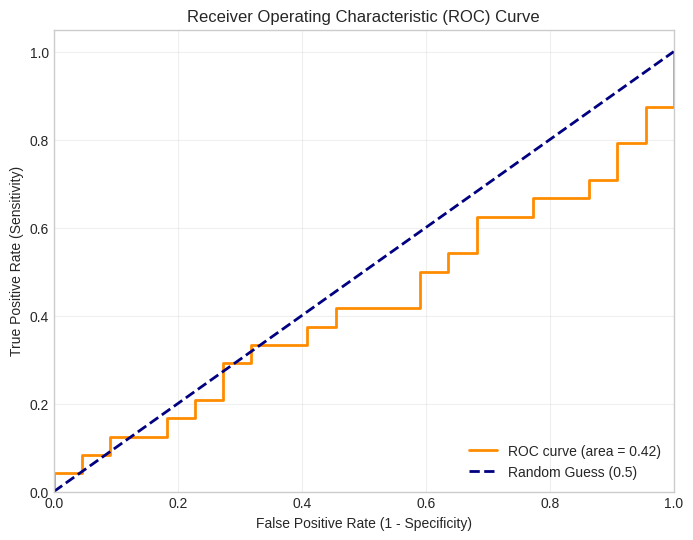

In [ ]:
from sklearn.metrics import roc_curve, auc

# ROC 커브 계산
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# ROC 커브 시각화
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### 📈 ROC-AUC (Area Under the ROC Curve) 상세 해석

**ROC 커브**는 모든 분류 임계값에서 분류 모델의 성능을 보여주는 그래프이며, **AUC**는 이 커브 아래의 면적을 의미합니다.

*   **정의**: 모델이 '상승' 확률을 얼마나 잘 정렬(Ranking)하는지 측정하는 지표입니다.
*   **해석**:
    *   **0.5**: **무작위 추측 (동전 던지기)** - 모델이 아무런 정보력이 없음을 의미합니다.
    *   **1.0**: **완벽한 분별력** - 모든 상승일과 하락일을 완벽하게 구분해냅니다.
    *   **0.5 미만**: 모델이 반대로 예측하고 있음을 의미합니다.
*   **특징**: 단순히 맞췄냐 틀렸냐(Accuracy)보다 모델이 상승할 날에 실제로 얼마나 더 높은 확률을 부여하는지(**분별력**)를 평가하기에 가장 적합한 지표입니다.

> **현재 결과 분석**: 그래프의 면적(AUC)이 0.5 근처라면 모델이 시장의 방향성을 거의 맞추지 못하고 있음을 의미하며, 피처를 개선하거나 모델 파라미터를 튜닝해야 한다는 신호로 해석할 수 있습니다.

### 📈 ROC-AUC (Area Under the ROC Curve) 상세 해석

**ROC 커브**는 모든 분류 임계값에서 분류 모델의 성능을 보여주는 그래프이며, **AUC**는 이 커브 아래의 면적을 의미합니다.

*   **0.5 (무작위 추측)**: 동전 던지기와 다를 바 없는 상태입니다. 모델이 주가 상승과 하락을 전혀 구별하지 못하고 있음을 뜻합니다.
*   **1.0 (완벽한 모델)**: 모든 상승일과 하락일을 100% 정확하게 분별해내는 이상적인 상태입니다.
*   **0.7 ~ 0.8**: 보통 준수한 성능으로 간주하며, 주식 예측에서는 0.6만 넘어도 유의미한 정보력이 있다고 보기도 합니다.

**현재 결과 분석**: 만약 AUC가 0.5 근처라면, 현재 사용한 7가지 피처들(과거 수익률, 이격도 등)이 내일의 테슬라 주가 방향을 설명하기에 부족하다는 증거입니다. 이 경우 더 많은 데이터나 뉴스 감성 분석 같은 추가 피처가 필요할 수 있습니다.

### 📈 ROC-AUC (Area Under the ROC Curve) 상세 해석

**ROC 커브**는 모든 분류 임계값에서 분류 모델의 성능을 보여주는 그래프이며, **AUC**는 이 커브 아래의 면적을 의미합니다.

*   **0.5 (무작위 추측)**: 동전 던지기와 다를 바 없는 상태입니다. 모델이 주가 상승과 하락을 전혀 구별하지 못하고 있음을 뜻합니다.
*   **1.0 (완벽한 모델)**: 모든 상승일과 하락일을 100% 정확하게 분별해내는 이상적인 상태입니다.
*   **성능 기준**: 주식 예측에서는 0.55~0.6만 넘어도 유의미한 정보력이 있다고 보며, 0.7 이상은 매우 우수한 성능으로 간주합니다.

**현재 결과 분석**:
현재 모델의 AUC 수치가 0.5 근처라면, 사용된 7가지 피처(수익률, 이격도 등)가 내일의 테슬라 주가 방향을 예측하기에는 변별력이 다소 부족하다는 것을 의미합니다. 성능을 높이기 위해서는 뉴스 심리 지수나 거래량 지표 같은 추가 데이터가 필요할 수 있습니다.

### 📊 혼동 행렬(Confusion Matrix) 수치 해석

앞서 출력된 그래프의 4가지 영역은 다음과 같은 의미를 가집니다 (테스트 데이터 기준):

1.  **True Negative (좌측 상단, 0-0)**:
    *   **의미**: 실제 **하락/보합**이었고, 모델도 **하락/보합**으로 정확히 예측한 경우입니다.
    *   **결과**: 불필요한 매수를 피하여 손실을 방지했습니다.

2.  **False Positive (우측 상단, 0-1)**:
    *   **의미**: 실제 **하락/보합**이었으나, 모델은 **상승**할 것이라고 잘못 예측한 경우입니다.
    *   **결과 (가짜 신호)**: 이 신호를 믿고 매수했다면 손실을 보았을 위험 구간입니다.

3.  **False Negative (좌측 하단, 1-0)**:
    *   **의미**: 실제 **상승**했으나, 모델은 **하락/보합**할 것이라고 잘못 예측한 경우입니다.
    *   **결과 (기회 비용)**: 실제 수익을 낼 수 있는 기회를 놓친 구간입니다.

4.  **True Positive (우측 하단, 1-1)**:
    *   **의미**: 실제 **상승**했고, 모델도 **상승**으로 정확히 예측한 경우입니다.
    *   **결과**: 모델의 신호대로 매수하여 수익을 실현할 수 있었던 성공적인 예측입니다.

> **Tip**: 주식 투자 관점에서는 손실을 방지하는 것이 중요하므로 **False Positive(가짜 신호)**를 줄이는 것이 모델 개선의 주요 목표 중 하나가 됩니다.

모델 정확도(Accuracy): 0.4348
ROC-AUC 점수: 0.4242


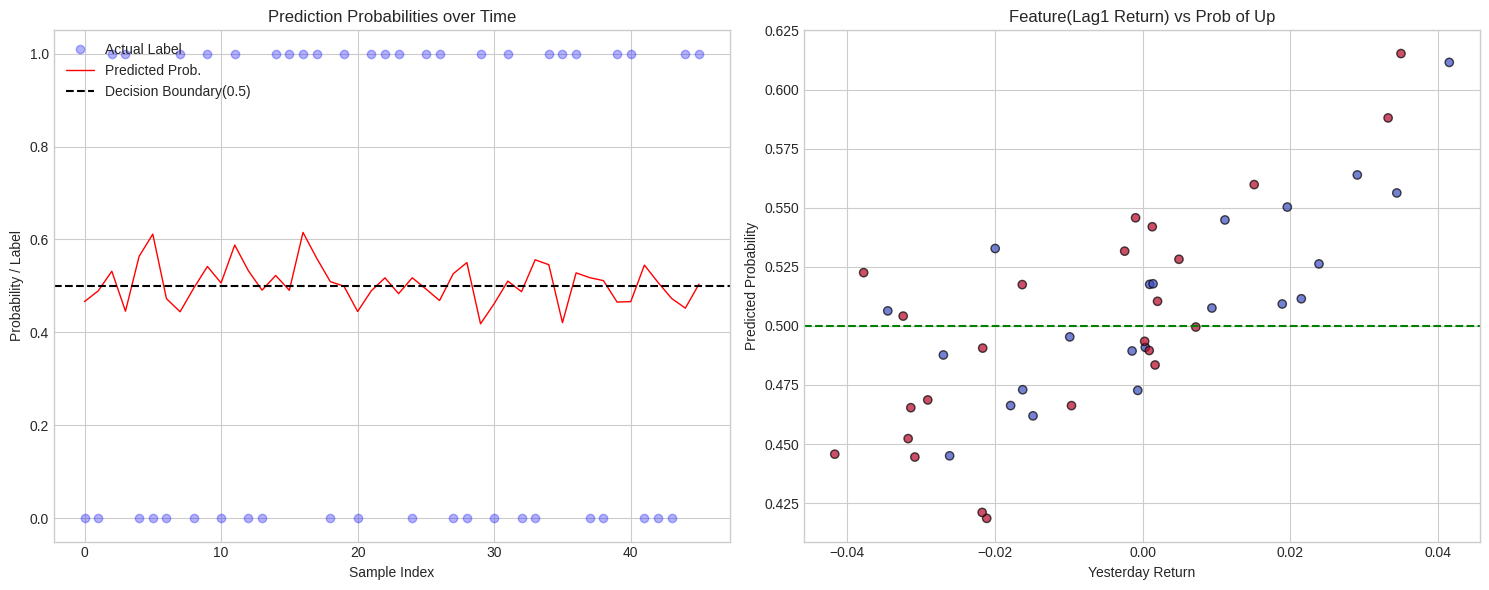

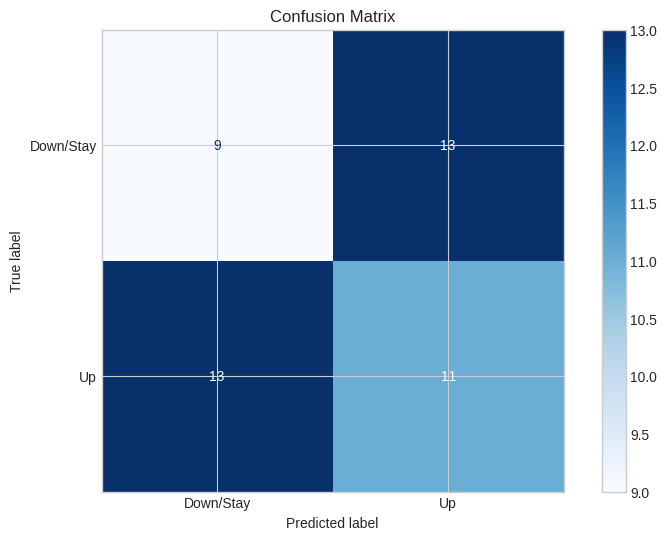

In [ ]:
# 6) 결과 분석 및 시각화

# 1. 성능 평가 지표
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
print(f'모델 정확도(Accuracy): {acc:.4f}')
print(f'ROC-AUC 점수: {auc:.4f}')

# 2. 방향성 확인을 위한 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (A) 예측 확률 vs 실제 라벨
# 모델이 예측한 확률이 0.5보다 크면 상승(1)으로 분류합니다.
axes[0].plot(y_test.values, 'o', label='Actual Label', alpha=0.3, color='blue')
axes[0].plot(y_proba, 'r-', label='Predicted Prob.', linewidth=1)
axes[0].axhline(0.5, color='black', linestyle='--', label='Decision Boundary(0.5)')
axes[0].set_title('Prediction Probabilities over Time')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Probability / Label')
axes[0].legend()

# (B) 주요 변수(전일 수익률)와 상승 확률의 관계
# 특정 변수가 변함에 따라 상승 확률이 어떻게 변하는지 확인 (로지스틱 곡선 형태)
axes[1].scatter(X_test['ret_lag1'], y_proba, c=y_test, cmap='coolwarm', edgecolors='k', alpha=0.7)
axes[1].axhline(0.5, color='green', linestyle='--')
axes[1].set_title('Feature(Lag1 Return) vs Prob of Up')
axes[1].set_xlabel('Yesterday Return')
axes[1].set_ylabel('Predicted Probability')

plt.tight_layout()
plt.show()

# 3. 혼동 행렬(Confusion Matrix)
# 실제 값 대비 모델이 얼마나 맞았는지 표로 확인합니다.
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down/Stay', 'Up'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

--- 테스트 데이터 분류 결과 (상위 10개) ---


,Actual,Predicted,Prob_Up
181,0,0,0.466286
182,0,0,0.489387
183,1,1,0.531623
184,1,0,0.445719
185,0,1,0.563868
186,0,1,0.611486
187,0,0,0.472702
188,1,0,0.444506
189,0,0,0.495340
190,1,1,0.541950


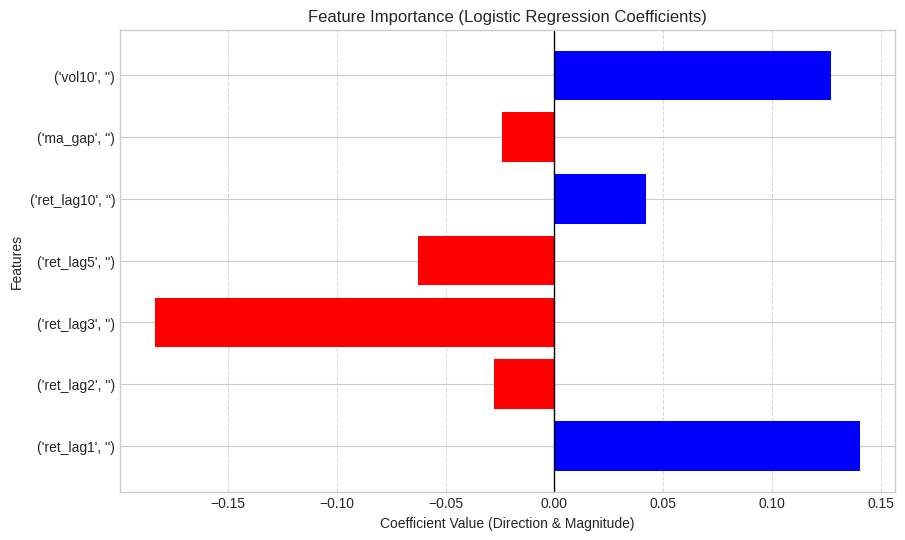


[해석 가이드]
- 양수(+) 계수(파랑): 해당 수치가 높을수록 '상승(1)'으로 예측할 확률이 높아짐
- 음수(-) 계수(빨강): 해당 수치가 높을수록 '하락(0)'으로 예측할 확률이 높아짐


In [ ]:
# 7) 분류 결과 상세 확인 및 변수 영향력 분석

# (A) 실제 값 vs 예측 값 비교 테이블 생성
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Prob_Up': y_proba
}, index=X_test.index)

print("--- 테스트 데이터 분류 결과 (상위 10개) ---")
display(results_df.head(10))

# (B) 로지스틱 회귀 계수(Coefficients) 시각화
# 어떤 변수가 '상승(1)' 예측에 긍정적/부정적 영향을 주는지 확인합니다.
coefs = clf.named_steps['logit'].coef_[0]
# 특성 이름이 튜플인 경우 문자열로 변환 (Matplotlib 오류 방지)
features_names = [str(col) if isinstance(col, tuple) else col for col in X.columns]

plt.figure(figsize=(10, 6))
plt.barh(features_names, coefs, color=['red' if c < 0 else 'blue' for c in coefs])
plt.axvline(0, color='black', lw=1)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Direction & Magnitude)')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\n[해석 가이드]")
print("- 양수(+) 계수(파랑): 해당 수치가 높을수록 '상승(1)'으로 예측할 확률이 높아짐")
print("- 음수(-) 계수(빨강): 해당 수치가 높을수록 '하락(0)'으로 예측할 확률이 높아짐")

## 7) (선택) 다중 분류로 확장
다중 분류는 `y_multi`를 타깃으로 사용하고, `LogisticRegression(multi_class='auto')`로 학습합니다.
보합(0) 비중이 너무 크면 예측이 ‘보합’으로 쏠릴 수 있으니, 임계치(thr)를 조정해 보세요.


In [ ]:
# --- Multi-class optional ---
# y_mc = df['y_multi']
# X_train, X_test, y_train, y_test = train_test_split(X, y_mc, test_size=0.2, shuffle=False)
# clf_mc = Pipeline(steps=[
#     ('scaler', StandardScaler()),
#     ('logit', LogisticRegression(max_iter=3000, C=1.0))
# ])
# clf_mc.fit(X_train, y_train)
# y_pred_mc = clf_mc.predict(X_test)
# print(classification_report(y_test, y_pred_mc, digits=4))


## ✅ 요약(3줄)
1) Logistic Regression은 ‘내일 상승할 확률’을 출력하는 **선형 확률 분류기**입니다.
2) 시계열에서는 **시간 분할**과 **정보누수 방지(스케일러 fit=train만)**가 핵심입니다.
3) 성능은 Accuracy뿐 아니라 **ROC-AUC, confusion matrix, naive baseline**과 함께 해석해야 합니다.

### ➡️ 다음 알고리즘
- Decision Tree / Random Forest로 비선형 경계와 상호작용을 학습하는 버전을 이어서 구현할 수 있습니다.
